In [77]:
from sklearn import manifold
from sklearn import datasets
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
import sklearn
from sklearn.model_selection import train_test_split 

In [33]:
digits = datasets.load_digits() #loading of dataset
print(digits.images.shape) 
print(digits.keys())

(1797, 8, 8)
dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])


In [35]:
print(digits.DESCR)

.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

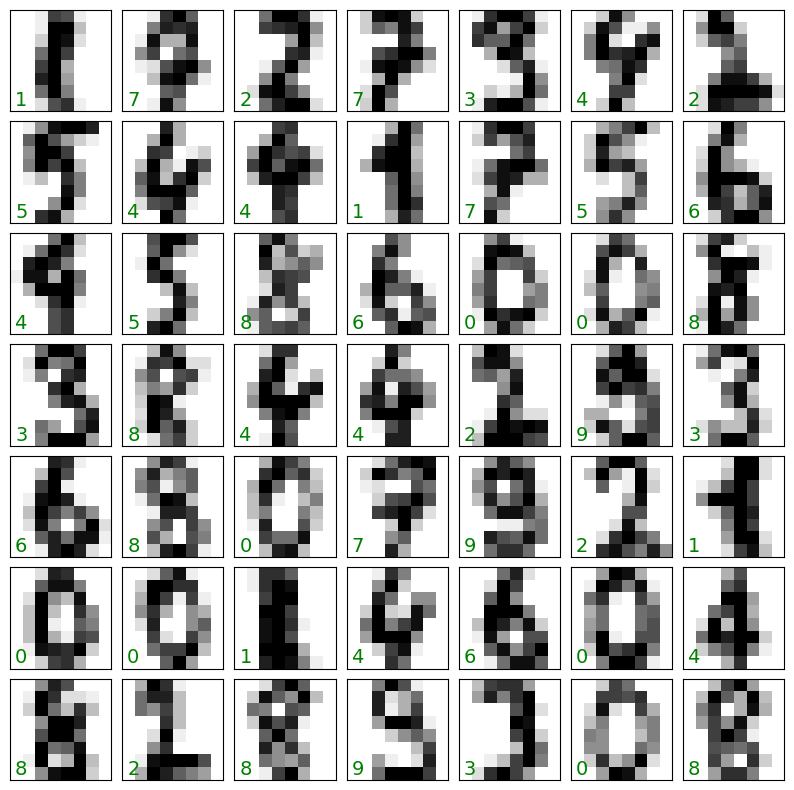

In [37]:
fig, axes = plt.subplots(7,7, figsize=(10, 10))
fig.subplots_adjust(hspace=0.1, wspace=0.1)

np.random.seed(42)
mychoices = np.random.choice(digits.images.shape[0],100)

for i, ax in enumerate(axes.flat):
    ax.imshow((digits.images[mychoices[i]]), 
              cmap='binary')
    ax.text(0.05, 0.05, str(digits.target[mychoices[i]]),transform=ax.transAxes, color='green', fontsize=14)
    ax.set_xticks([])
    ax.set_yticks([])

In [38]:
print(digits.data.shape)

# The images themselves
print(digits.images[0])

# The data for use in our algorithms
print(digits.data[0])

# The labels
print(digits.target)
print(digits.target[0])

(1797, 64)
[[ 0.  0.  5. 13.  9.  1.  0.  0.]
 [ 0.  0. 13. 15. 10. 15.  5.  0.]
 [ 0.  3. 15.  2.  0. 11.  8.  0.]
 [ 0.  4. 12.  0.  0.  8.  8.  0.]
 [ 0.  5.  8.  0.  0.  9.  8.  0.]
 [ 0.  4. 11.  0.  1. 12.  7.  0.]
 [ 0.  2. 14.  5. 10. 12.  0.  0.]
 [ 0.  0.  6. 13. 10.  0.  0.  0.]]
[ 0.  0.  5. 13.  9.  1.  0.  0.  0.  0. 13. 15. 10. 15.  5.  0.  0.  3.
 15.  2.  0. 11.  8.  0.  0.  4. 12.  0.  0.  8.  8.  0.  0.  5.  8.  0.
  0.  9.  8.  0.  0.  4. 11.  0.  1. 12.  7.  0.  0.  2. 14.  5. 10. 12.
  0.  0.  0.  0.  6. 13. 10.  0.  0.  0.]
[0 1 2 ... 8 9 8]
0


In [ ]:
iso = sklearn.manifold.Isomap(n_neighbors=50, n_components=2) 
#Non-linear dimensionality reduction through Isometric Mapping

trasf = iso.fit_transform(digits.data) #make fit and transform together
print(trasf.shape)
print(trasf)

In [67]:
print(len(digits.target))
print(digits.target)

1797
[0 1 2 ... 8 9 8]


C:\Users\User\AppData\Local\Temp\ipykernel_18056\3746869305.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


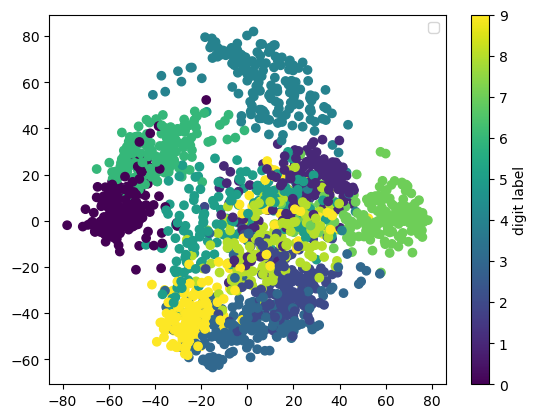

In [75]:
plt.scatter(trasf[:, 0], trasf[:, 1], c=digits.target)
plt.colorbar(label='digit label')
plt.legend()

In [91]:
y = digits.target 

In [95]:
#I have to perform this on the reduced dataset on on the starting dataset?
X_train, X_test, y_train, y_test = train_test_split(trasf, y, test_size=0.2, random_state=42) #80% of the dataset goes in training dataset

In [97]:
#print(X_train)

In [99]:
#print(X_test)

In [101]:
#y_train 

In [103]:
#y_test

In [240]:
## class logistic regression 

In [105]:
model = LogisticRegression(solver='sag') #model done with Logistic regression 
print(model)

LogisticRegression(solver='sag')


(1437, 2)
(1437,)


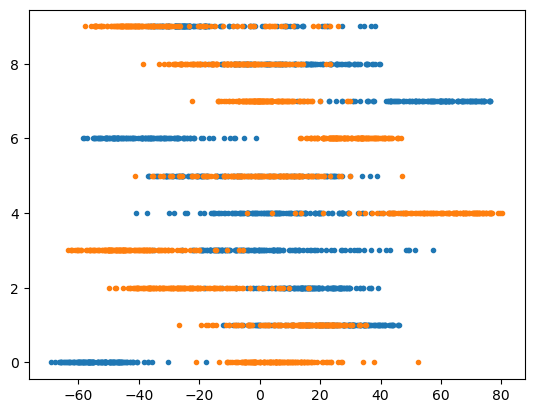

In [115]:
print(X_train.shape)
print(y_train.shape)
plt.plot(X_train,y_train, ".") 

In [117]:
model.fit(X_train, y_train)
pred_test = model.predict(X_test) #etichette predette
pred_train = model.predict(X_train)

C:\Users\User\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [119]:
acc_pred = accuracy_score(y_test, pred_test)
acc_train = accuracy_score(y_train, pred_train)

In [121]:
print(acc_pred)
print(acc_train)

0.7444444444444445
0.7070285316631872


In [123]:
print(confusion_matrix(y_train, pred_train))

[[131   0   0   0   1   0  13   0   0   0]
 [  0 101   1   0   1  22   1  12  15   1]
 [  0   5  71  38   0   7   0   2  20   1]
 [  0   0  12 114   0   1   0   3   3  16]
 [  0   4   0   0 124   0   4   3   0   0]
 [ 10  23   1   0   2  58   7   3  13  18]
 [  9   0   0   0   6   0 131   0   0   0]
 [  0  10   1   0   0   0   0 130   4   0]
 [  0  15  22   4   0  23   0  11  54  15]
 [  1   7   2   8   1   6   0   4   9 102]]


In [125]:
print(confusion_matrix(y_test, pred_test))

[[30  0  0  0  0  0  3  0  0  0]
 [ 0 19  0  0  0  4  0  2  3  0]
 [ 0  0 21  6  0  0  0  0  6  0]
 [ 0  0  3 28  0  1  0  0  0  2]
 [ 0  0  0  0 45  0  1  0  0  0]
 [ 2 12  0  0  0 21  2  1  0  9]
 [ 4  0  0  0  0  0 31  0  0  0]
 [ 0  1  0  0  0  0  0 30  3  0]
 [ 0  4  1  2  0  4  0  2 14  3]
 [ 0  2  0  4  0  1  0  4  0 29]]


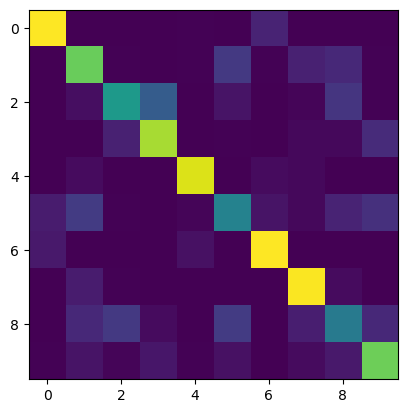

In [137]:
plt.imshow(confusion_matrix(y_train, pred_train))

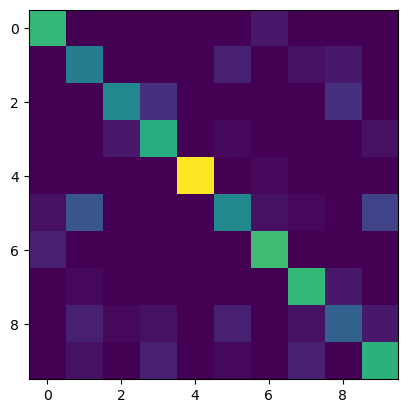

In [139]:
plt.imshow(confusion_matrix(y_test, pred_test))